## Assignment:
### Urban Architecture Failure

In [1]:
# We will first import all the libraries needed for this assignment
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score,classification_report,confusion_matrix,ConfusionMatrixDisplay

#### Will load the data

In [2]:
# Will also first launch the google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Lets access the data from google drive and import the file.
urban = pd.read_csv('/content/drive/MyDrive/ITNPBD6_Final_ML/urbandata.csv')
urban.head()    # To display first 5 rows of the imported dataset

,inspector_id,material_flexibility,structural_mass_ratio,recent_precipitation,infrastructure_age,surface_debris,vibration_exposure,asset_density,inspection_season,inspection_window,moisture_stress,failure
0,5,31.762605,12.891996,4.711064,71.480592,9.429642,5.177088,2.9944,summer,afternoon,0.06,1
1,7,30.770158,11.835563,3.315888,60.300892,8.655641,4.927622,2.6808,spring,morning,0.01,0
2,6,31.591296,11.738267,2.425562,56.367965,9.017137,4.910945,2.5294,autumn,night,0.02,0
3,5,30.834649,11.622881,2.164486,53.135138,8.864650,4.949554,2.4810,autumn,afternoon,0.02,1
4,2,33.315981,12.616065,4.557082,77.482269,9.549344,5.047689,3.0460,summer,morning,0.07,1


In [4]:
# Lets find out the quantity

print (f'Rows: {urban.shape[0]}')
print (f'Columns: {urban.shape[1]}')

Rows: 456
Columns: 12


In [5]:
print (urban.dtypes)    # to check the datatypes of the colums

inspector_id               int64
material_flexibility     float64
structural_mass_ratio    float64
recent_precipitation     float64
infrastructure_age       float64
surface_debris           float64
vibration_exposure       float64
asset_density            float64
inspection_season         object
inspection_window         object
moisture_stress          float64
failure                    int64
dtype: object


In [6]:
urban.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 456 entries, 0 to 455
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   inspector_id           456 non-null    int64  
 1   material_flexibility   456 non-null    float64
 2   structural_mass_ratio  455 non-null    float64
 3   recent_precipitation   454 non-null    float64
 4   infrastructure_age     452 non-null    float64
 5   surface_debris         456 non-null    float64
 6   vibration_exposure     455 non-null    float64
 7   asset_density          456 non-null    float64
 8   inspection_season      456 non-null    object 
 9   inspection_window      456 non-null    object 
 10  moisture_stress        453 non-null    float64
 11  failure                456 non-null    int64  
dtypes: float64(8), int64(2), object(2)
memory usage: 42.9+ KB


In [7]:
# As 'inspection_season' and 'inspection_window' are non numerical columns
# Lets find out the uniq values in them

print (urban['inspection_season'].unique())
print (urban['inspection_window'].unique())
print (urban ['inspection_season'].value_counts())
print (urban ['inspection_window'].value_counts())

['summer' 'spring' 'autumn' 'winter' 'sumer']
['afternoon' 'morning' 'night' 'morni7ng']
inspection_season
summer    133
autumn    122
winter    115
spring     85
sumer       1
Name: count, dtype: int64
inspection_window
night        172
morning      148
afternoon    135
morni7ng       1
Name: count, dtype: int64


In [8]:
# As we can clearly see there are some typos in the spellings we can replace them

urban['inspection_season'] = urban['inspection_season'].replace({'sumer': 'summer'})
urban['inspection_window'] = urban['inspection_window'].replace({'morni7ng': 'morning'})

# Will verify the changes

print (urban['inspection_season'].unique())
print (urban['inspection_window'].unique())
print (urban ['inspection_season'].value_counts())
print (urban ['inspection_window'].value_counts())

['summer' 'spring' 'autumn' 'winter']
['afternoon' 'morning' 'night']
inspection_season
summer    134
autumn    122
winter    115
spring     85
Name: count, dtype: int64
inspection_window
night        172
morning      149
afternoon    135
Name: count, dtype: int64


In [9]:
# Statistical overview of the Data
urban.describe(include='all')

,inspector_id,material_flexibility,structural_mass_ratio,recent_precipitation,infrastructure_age,surface_debris,vibration_exposure,asset_density,inspection_season,inspection_window,moisture_stress,failure
count,456.000000,456.000000,455.000000,454.000000,452.000000,456.000000,455.000000,456.000000,456,456,453.000000,456.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,3,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,summer,night,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,134,172,NaN,NaN
mean,5.730263,32.592037,12.089241,3.110861,68.532487,9.271769,4.962680,2.654610,NaN,NaN,0.037108,0.368421
std,2.921622,4.738187,0.591701,1.365354,14.490899,0.790136,0.080109,0.268216,NaN,NaN,0.051781,0.482906
min,1.000000,24.924765,11.506094,0.000000,41.087602,7.426926,4.743956,2.200000,NaN,NaN,0.000000,0.000000
25%,3.000000,30.496861,11.672524,2.140594,58.594494,8.744313,4.911817,2.451540,NaN,NaN,0.010000,0.000000
50%,6.000000,31.902116,11.863909,2.925396,64.789151,9.125281,4.960576,2.595360,NaN,NaN,0.020000,0.000000
75%,8.000000,34.026756,12.332858,4.314350,76.739522,9.771380,5.010956,2.845200,NaN,NaN,0.040000,1.000000


###### In The above describe section, we can observe that the target Value 'failure' is slightly imbalanced so we will have to chcek the balance distribution later in the process of analysing this data.

In [10]:
# To check the duplicates in row
print (f'Duplicate rows found: {urban.duplicated().sum()}')

Duplicate rows found: 0


In [11]:
# Lets check the missing values
print (urban.isnull().sum())

inspector_id             0
material_flexibility     0
structural_mass_ratio    1
recent_precipitation     2
infrastructure_age       4
surface_debris           0
vibration_exposure       1
asset_density            0
inspection_season        0
inspection_window        0
moisture_stress          3
failure                  0
dtype: int64


In [12]:
# Now lets first seperate target (dependent Variable) and features (independent variable)

X = urban.drop(columns=['failure'])
y = urban['failure']

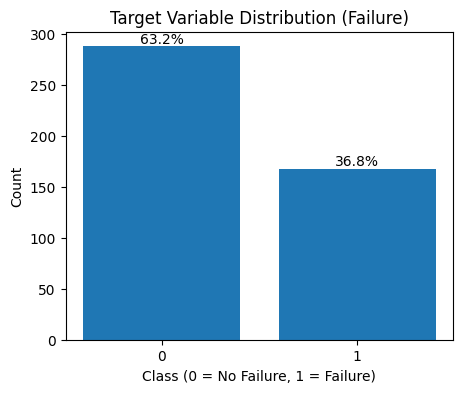

In [13]:
# Will also check the target distribution

# Now lets check the target variable value balance.

plt.figure(figsize=(5,4))

y = urban['failure']
counts = y.value_counts()
percentages = y.value_counts(normalize=True) * 100

# Will plot a bar plot
bars = plt.bar(counts.index, counts.values)

# To add a percentage labels on top
for i, bar in enumerate(bars):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{percentages.iloc[i]:.1f}%",
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title("Target Variable Distribution (Failure)")
plt.xlabel("Class (0 = No Failure, 1 = Failure)")
plt.ylabel("Count")
plt.xticks([0, 1])
plt.show()

###### As we can see, there is a moderate level of imbalance 63/37, I decided to not to further balance the target variable to preserve all the available data and to maintain an original distribution.

In [14]:
# Now before we do any operations on data lets split the data to avoid any leakage
# Will do 70% train, 15% validation and 15% test

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42, stratify=y_temp
)

print(f"Train set: {X_train.shape[0]} rows")
print(f"Validation set: {X_val.shape[0]} rows")
print(f"Test set: {X_test.shape[0]} rows")

# Also make copies to safely preprocess
X_train_clean = X_train.copy()
X_val_clean = X_val.copy()
X_test_clean = X_test.copy()

Train set: 319 rows
Validation set: 68 rows
Test set: 69 rows


In [15]:
# Now impute missing values with median; fitting only on train data

missing_cols = ['structural_mass_ratio','recent_precipitation','infrastructure_age','vibration_exposure','moisture_stress']

train_medians = {}

for col in missing_cols:
    median_val = X_train_clean[col].median()
    train_medians[col] = median_val

    X_train_clean[col] = X_train_clean[col].fillna(median_val)
    X_val_clean[col] = X_val_clean[col].fillna(median_val)
    X_test_clean[col] = X_test_clean[col].fillna(median_val)

In [16]:
# Now lets check missing values in all the datasets

print (X_train_clean.isnull().sum())
print (X_val_clean.isnull().sum())
print (X_test_clean.isnull().sum())

inspector_id             0
material_flexibility     0
structural_mass_ratio    0
recent_precipitation     0
infrastructure_age       0
surface_debris           0
vibration_exposure       0
asset_density            0
inspection_season        0
inspection_window        0
moisture_stress          0
dtype: int64
inspector_id             0
material_flexibility     0
structural_mass_ratio    0
recent_precipitation     0
infrastructure_age       0
surface_debris           0
vibration_exposure       0
asset_density            0
inspection_season        0
inspection_window        0
moisture_stress          0
dtype: int64
inspector_id             0
material_flexibility     0
structural_mass_ratio    0
recent_precipitation     0
infrastructure_age       0
surface_debris           0
vibration_exposure       0
asset_density            0
inspection_season        0
inspection_window        0
moisture_stress          0
dtype: int64


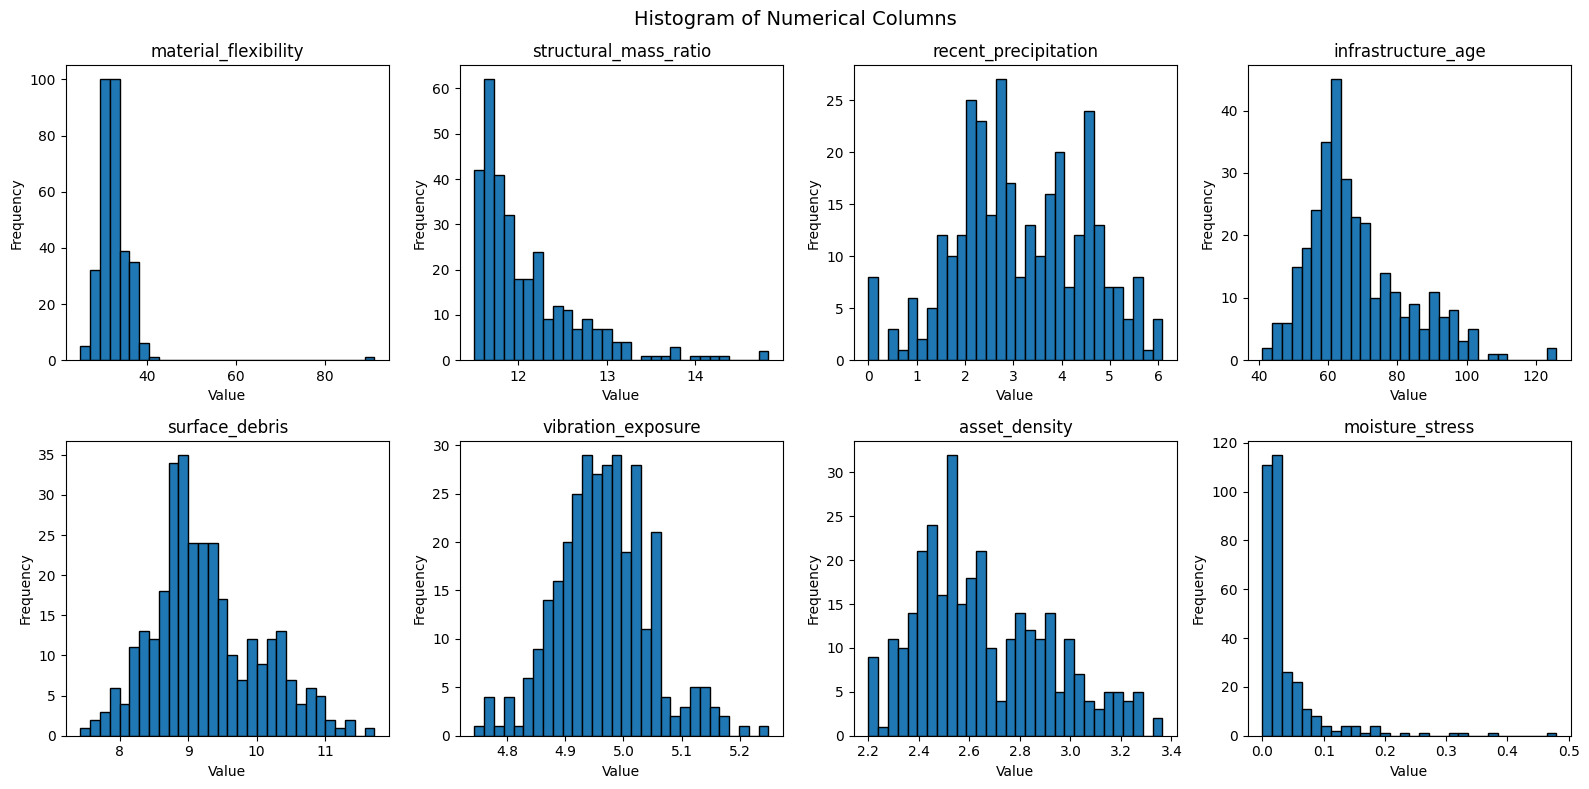

In [17]:
# Now lets visualise all the numeric columns using training set only

num_cols = ['material_flexibility','structural_mass_ratio','recent_precipitation','infrastructure_age','surface_debris','vibration_exposure','asset_density','moisture_stress']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Histogram of Numerical Columns', fontsize=14)

for i, col in enumerate(num_cols):
    row = i // 4
    col_idx = i % 4
    ax = axes[row, col_idx]
    ax.hist(X_train_clean[col].dropna(), bins=30, edgecolor='black')
    ax.set_title(col)
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

###### We can visually see in "material_flexibility" column, one value is located on very distant right side of the plot above 90, away from all the main distribution of data. There we suspect an outlier. So lets work on that outlier to fix it.

In [18]:
# will do outlier handelling in "material_flexibility" using IQR bonds

material_flex_before = X_train_clean['material_flexibility'].copy()

q1 = material_flex_before.quantile(0.25)
q3 = material_flex_before.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
replace_median = material_flex_before.median()

print ("outlier bounds for material_flexibility(for training set only)")
print (f"lower={lower_bound:.4f}, upper={upper_bound:.4f}")
print (f"replacement_median={replace_median:.4f}")

outlier bounds for material_flexibility(for training set only)
lower=25.6489, upper=38.6837
replacement_median=31.8474


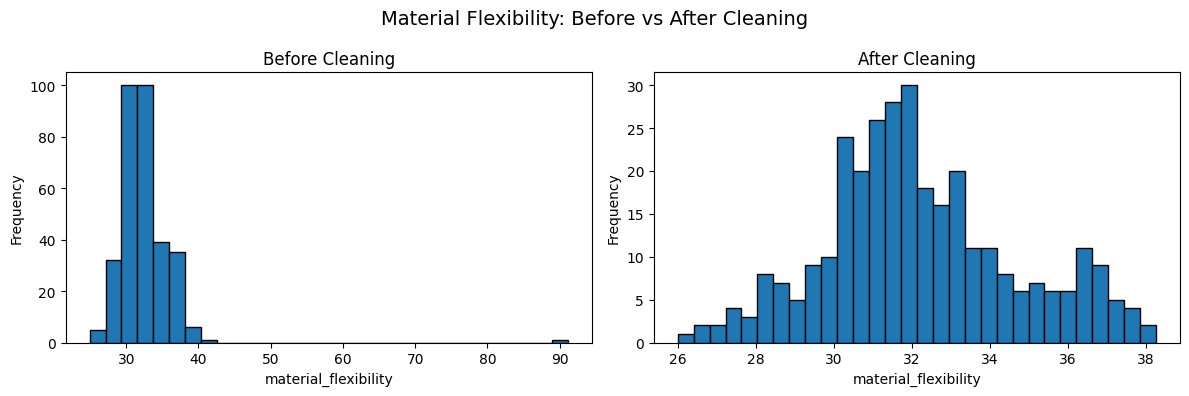

In [19]:
# Now lets plot a graph of "material_flexibility"before and after outlier handelling

material_flex_after = np.where(
    (material_flex_before < lower_bound) | (material_flex_before > upper_bound),
    replace_median,
    material_flex_before
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Before Clening

axes[0].hist(material_flex_before.dropna(), bins=30, edgecolor='black')
axes[0].set_title('Before Cleaning')
axes[0].set_xlabel('material_flexibility')
axes[0].set_ylabel('Frequency')

# After cleaning

axes[1].hist(pd.Series(material_flex_after).dropna(), bins=30, edgecolor='black')
axes[1].set_title('After Cleaning')
axes[1].set_xlabel('material_flexibility')
axes[1].set_ylabel('Frequency')

plt.suptitle('Material Flexibility: Before vs After Cleaning', fontsize=14)
plt.tight_layout()
plt.show()

In [20]:
# Now will apply the same training set bounds to all the dataset

for df in [X_train_clean, X_val_clean, X_test_clean]:
    df['material_flexibility'] = np.where(
        (df['material_flexibility'] < lower_bound) | (df['material_flexibility'] > upper_bound),
        replace_median,
        df['material_flexibility']
    )

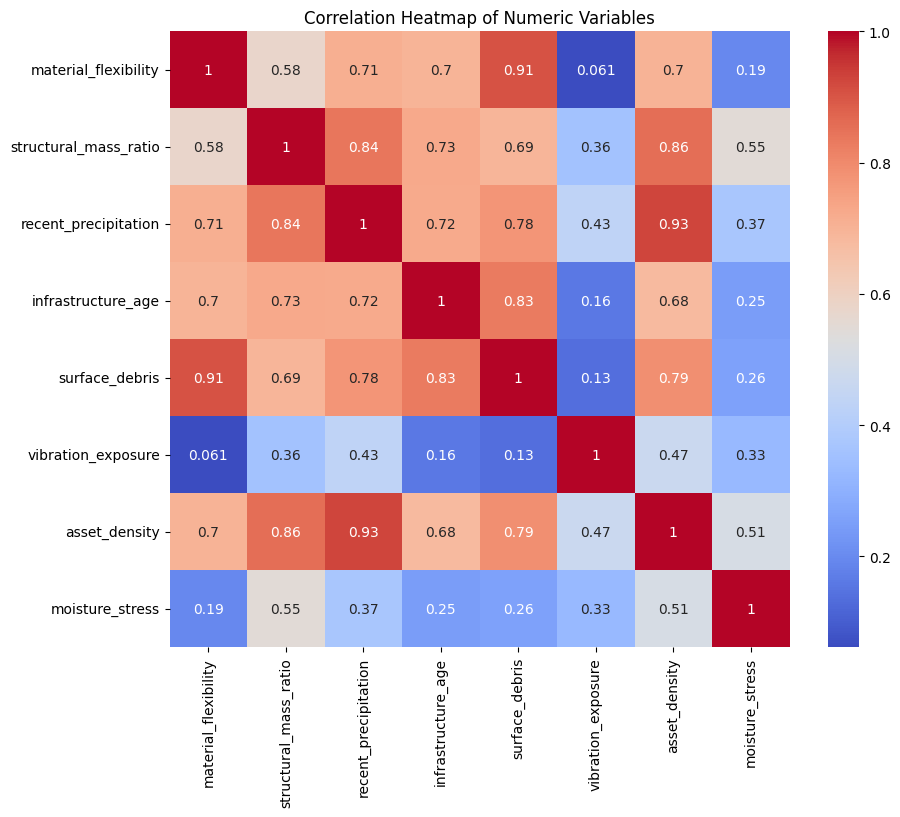

In [21]:
# lets draw the heatmap of the numeric variables

numeric_cols = ['material_flexibility','structural_mass_ratio','recent_precipitation','infrastructure_age','surface_debris','vibration_exposure','asset_density','moisture_stress']

plt.figure(figsize=(10, 8))
sns.heatmap(X_train_clean[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Numeric Variables')
plt.show()

In [22]:
# Now lets apply one hot encoding only on traing dataset
# For categorical columns of "inspection_season" and "inspection_window"
# This will convert the categorical data into numerical binary column for every uniqe value

cat_cols = ['inspection_season', 'inspection_window']

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

X_train_cat = encoder.fit_transform(X_train_clean[cat_cols])
X_val_cat = encoder.transform(X_val_clean[cat_cols])
X_test_cat = encoder.transform(X_test_clean[cat_cols])

encoded_cols = encoder.get_feature_names_out(cat_cols)

X_train_cat_df = pd.DataFrame(X_train_cat, columns=encoded_cols, index=X_train_clean.index)
X_val_cat_df = pd.DataFrame(X_val_cat, columns=encoded_cols, index=X_val_clean.index)
X_test_cat_df = pd.DataFrame(X_test_cat, columns=encoded_cols, index=X_test_clean.index)

# Now will drop original categorical columns and join encoded columns
X_train_clean = X_train_clean.drop(columns=cat_cols).join(X_train_cat_df)
X_val_clean = X_val_clean.drop(columns=cat_cols).join(X_val_cat_df)
X_test_clean = X_test_clean.drop(columns=cat_cols).join(X_test_cat_df)

In [23]:
# Lets do the feature scalling to compare numberical columns and one hot encoded categorical columns in comparable scale

scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train_clean.drop(columns=['inspector_id']))
X_val_sc = scaler.transform(X_val_clean.drop(columns=['inspector_id']))
X_test_sc = scaler.transform(X_test_clean.drop(columns=['inspector_id']))

In [24]:
# Now as data is clean and split for modelling
# Lets start modelling and hyperparameter tuning with logistic regression

lr_results = []

for C_val in [0.01, 0.1, 1.0, 10.0]:
    model = LogisticRegression(C=C_val, max_iter=1000, random_state=42)
    model.fit(X_train_sc, y_train)

    val_pred = model.predict(X_val_sc)

    acc = accuracy_score(y_val, val_pred)
    f1 = f1_score(y_val, val_pred)

    lr_results.append({
        "model": "Logistic Regression",
        "hyperparameter": f"C={C_val}",
        "Val_accuracy": acc,
        "Val_f1_score": f1
    })

lr_results_df = pd.DataFrame(lr_results)
print("Logistic Regression Validation Results:")
print(lr_results_df)

Logistic Regression Validation Results:
                 model hyperparameter  Val_accuracy  Val_f1_score
0  Logistic Regression         C=0.01      0.955882      0.938776
1  Logistic Regression          C=0.1      0.970588      0.960000
2  Logistic Regression          C=1.0      0.955882      0.941176
3  Logistic Regression         C=10.0      0.955882      0.941176


In [25]:
# Will try Decision Tree model now

dt_results = []

for depth in [3, 5, 7, 9]:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train_clean, y_train)

    val_pred = model.predict(X_val_clean)

    acc = accuracy_score(y_val, val_pred)
    f1 = f1_score(y_val, val_pred)

    dt_results.append({
        "model": "Decision Tree",
        "hyperparameter": f"max_depth={depth}",
        "Val_accuracy": acc,
        "Val_f1": f1
    })

dt_results_df = pd.DataFrame(dt_results)
print("Decision Tree Validation Results:")
print(dt_results_df)

Decision Tree Validation Results:
           model hyperparameter  Val_accuracy    Val_f1
0  Decision Tree    max_depth=3      0.926471  0.905660
1  Decision Tree    max_depth=5      0.941176  0.923077
2  Decision Tree    max_depth=7      0.911765  0.888889
3  Decision Tree    max_depth=9      0.911765  0.888889


In [26]:
# Now will try neural Network model

nn_results = []

for arch in [(50,), (100,), (50, 50), (100, 50)]:
    model = MLPClassifier(hidden_layer_sizes=arch, max_iter=500, random_state=42)
    model.fit(X_train_sc, y_train)

    val_pred = model.predict(X_val_sc)

    acc = accuracy_score(y_val, val_pred)
    f1 = f1_score(y_val, val_pred)

    nn_results.append({
        "model": "Neural Network",
        "hyperparameter": f"layers={arch}",
        "Val_accuracy": acc,
        "Val_f1": f1
    })

nn_results_df = pd.DataFrame(nn_results)
print("Neural Network Validation Results:")
print(nn_results_df)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Neural Network Validation Results:
            model    hyperparameter  Val_accuracy    Val_f1
0  Neural Network      layers=(50,)      0.941176  0.923077
1  Neural Network     layers=(100,)      0.941176  0.923077
2  Neural Network   layers=(50, 50)      0.911765  0.888889
3  Neural Network  layers=(100, 50)      0.926471  0.905660


In [27]:
# Lets Combine all results
all_results = pd.concat([
    lr_results_df.rename(columns={"Val_f1_score": "Val_f1"}),
    dt_results_df,
    nn_results_df
], ignore_index=True)

# Find best model overall
best_row = all_results.loc[all_results['Val_f1'].idxmax()]

print("Best Model Overall:")
print(best_row)

Best Model Overall:
model             Logistic Regression
hyperparameter                  C=0.1
Val_accuracy                 0.970588
Val_f1                           0.96
Name: 1, dtype: object


In [28]:
# Now wil combine train and validation
X_trainval = pd.concat([X_train_clean, X_val_clean])
y_trainval = pd.concat([y_train, y_val])

# And will scale again
scaler_final = StandardScaler()
X_trainval_sc = scaler_final.fit_transform(X_trainval.drop(columns=['inspector_id']))
X_test_sc_final = scaler_final.transform(X_test_clean.drop(columns=['inspector_id']))

In [29]:
# Now will train final model

#final_model = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
#final_model.fit(X_trainval_sc, y_trainval)

best_model_name = best_row['model']
best_hp = best_row['hyperparameter']

if best_model_name == "Logistic Regression":
    best_C = float(best_hp.split('=')[1])
    final_model = LogisticRegression(C=best_C, max_iter=1000, random_state=42)
    final_model.fit(X_trainval_sc, y_trainval)
    test_pred = final_model.predict(X_test_sc_final)

elif best_model_name == "Decision Tree":
    best_depth = int(best_hp.split('=')[1])
    final_model = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
    final_model.fit(X_trainval, y_trainval)
    test_pred = final_model.predict(X_test_clean)

elif best_model_name == "Neural Network":
    best_arch = eval(best_hp.replace("layers=", ""))
    final_model = MLPClassifier(hidden_layer_sizes=best_arch, max_iter=500, random_state=42)
    final_model.fit(X_trainval_sc, y_trainval)
    test_pred = final_model.predict(X_test_sc_final)

In [30]:
# This will be final test evaluation

test_acc = accuracy_score(y_test, test_pred)
test_f1 = f1_score(y_test, test_pred)

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test F1 Score: {test_f1:.4f}")

Test Accuracy: 0.9420
Test F1 Score: 0.9167


In [31]:
# Will also do the classification report

print(classification_report(y_test, test_pred))

              precision    recall  f1-score   support

           0       0.93      0.98      0.96        44
           1       0.96      0.88      0.92        25

    accuracy                           0.94        69
   macro avg       0.95      0.93      0.94        69
weighted avg       0.94      0.94      0.94        69



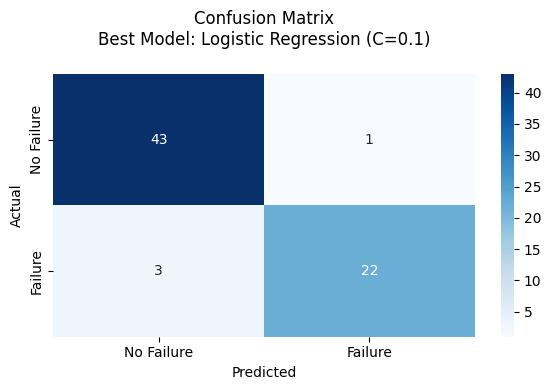

In [32]:
# Based on this will do the confusion matrix now and will also display best model and score

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, test_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Failure', 'Failure'],
            yticklabels=['No Failure', 'Failure'])

plt.title(
    f"Confusion Matrix\n"
    f"Best Model: {best_model_name} ({best_hp})\n"
)

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()